### *Cell 1: Importing Required Libraries*

In [1]:
# Importing essential libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.stats import chi2_contingency, ttest_ind


### *Cell 2: Loading and Exploring the Dataset*

In [2]:
# Load dataset
DATA_PATH = r"C:\Users\HP\Documents\Project_Datasets\customer_segmentation & abtesting_Dataset.xlsx"
df = pd.read_excel(DATA_PATH)

# Quick inspection
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Missing values per column:\n", df.isna().sum())

# Preview first 5 rows
df.head()

Shape: (10000, 7)
Columns: ['CustomerID', 'Age', 'Income', 'Purchases', 'CampaignGroup', 'Clicked', 'AmountSpent']
Missing values per column:
 CustomerID       0
Age              0
Income           0
Purchases        0
CampaignGroup    0
Clicked          0
AmountSpent      0
dtype: int64


,CustomerID,Age,Income,Purchases,CampaignGroup,Clicked,AmountSpent
0,1,52,67780,Fashion,A,No,356
1,2,53,77138,BabyProducts,B,Yes,35
2,3,35,110382,BabyProducts,B,Yes,235
3,4,56,62503,Fashion,B,No,247
4,5,49,77893,BabyProducts,B,No,459


### *Cell 3: Customer Segmentation with K-Means*

In [3]:
# One-hot encode purchase categories for clustering
df_seg = pd.get_dummies(df, columns=["Purchases"], drop_first=False)

# Features to include in clustering
features = ["Age", "Income", "AmountSpent"] + [c for c in df_seg.columns if c.startswith("Purchases_")]
X = df_seg[features]

# Scale numeric features to bring them on similar scale
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[["Age", "Income", "AmountSpent"]] = scaler.fit_transform(X_scaled[["Age", "Income", "AmountSpent"]])

# Run KMeans clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(X_scaled)

# Segment distribution
df["Segment"].value_counts()

Segment
3    2575
0    2481
2    2478
1    2466
Name: count, dtype: int64

### *Cell 4: Segment Profiling*

In [4]:
# Segment profiles: average age, income, spending
segment_profile = df.groupby("Segment").agg({
    "Age":"mean",
    "Income":"mean",
    "AmountSpent":"mean",
    "CustomerID":"count"
}).rename(columns={"CustomerID":"Num_Customers"})

segment_profile.round(2)

,Age,Income,AmountSpent,Num_Customers
Segment,,,,
0,42.06,97219.33,370.60,2481
1,54.55,67155.00,141.26,2466
2,28.80,72873.46,125.23,2478
3,38.81,42188.93,365.70,2575


### *Cell 5: A/B Testing (Overall Campaign Performance)*

In [5]:
# Cross-tabulation of campaign vs clicks
ct = pd.crosstab(df["CampaignGroup"], df["Clicked"])

# Chi-square test
chi2, p_chi, dof, exp = chi2_contingency(ct.values)

# Conversion rates
conv_A = (df.loc[df["CampaignGroup"]=="A", "Clicked"]=="Yes").mean()
conv_B = (df.loc[df["CampaignGroup"]=="B", "Clicked"]=="Yes").mean()
nA, nB = (df["CampaignGroup"]=="A").sum(), (df["CampaignGroup"]=="B").sum()

# Standard error for CI
se = np.sqrt(conv_A*(1-conv_A)/nA + conv_B*(1-conv_B)/nB)
lift = conv_B - conv_A
z = 1.96
ci_lo, ci_hi = lift - z*se, lift + z*se

# Revenue difference (Welch t-test + Cohen’s d)
amt_A = df.loc[df["CampaignGroup"]=="A", "AmountSpent"].to_numpy()
amt_B = df.loc[df["CampaignGroup"]=="B", "AmountSpent"].to_numpy()
t_stat, p_t = ttest_ind(amt_A, amt_B, equal_var=False)

# Effect size function
def cohens_d_welch(a, b):
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)
    s = np.sqrt((var_a + var_b) / 2)
    return (np.mean(b) - np.mean(a)) / s if s != 0 else np.nan

cohen_d = cohens_d_welch(amt_A, amt_B)

print("Counts -> A:", nA, " B:", nB)
print("CTR -> A: {:.3%}, B: {:.3%}, Lift (B−A): {:.3%}".format(conv_A, conv_B, lift))
print("Chi² p-value -> {:.4f}".format(p_chi))
print("95% CI for CTR lift (B−A): [{:.3%}, {:.3%}]".format(ci_lo, ci_hi))
print("Revenue -> A: {:.2f}, B: {:.2f}, Diff (B−A): {:.2f}".format(amt_A.mean(), amt_B.mean(), amt_B.mean()-amt_A.mean()))
print("Welch t-test p-value -> {:.4f}, Cohen’s d: {:.3f}".format(p_t, cohen_d))

Counts -> A: 5081  B: 4919
CTR -> A: 40.130%, B: 39.419%, Lift (B−A): -0.711%
Chi² p-value -> 0.4801
95% CI for CTR lift (B−A): [-2.630%, 1.207%]
Revenue -> A: 253.81, B: 250.09, Diff (B−A): -3.73
Welch t-test p-value -> 0.1970, Cohen’s d: -0.026


### *Cell 6: A/B Testing by Segment*

In [6]:
# Segment-level A/B testing
rows = []
for seg in sorted(df["Segment"].unique()):
    sub = df[df["Segment"] == seg]
    
    # CTR test
    ct = pd.crosstab(sub["CampaignGroup"], sub["Clicked"])
    if ct.shape == (2, 2):
        chi2, p_ctr, _, _ = chi2_contingency(ct.values)
        ctr_A = (sub.loc[sub["CampaignGroup"]=="A", "Clicked"]=="Yes").mean()
        ctr_B = (sub.loc[sub["CampaignGroup"]=="B", "Clicked"]=="Yes").mean()
        ctr_lift = ctr_B - ctr_A
    else:
        p_ctr, ctr_A, ctr_B, ctr_lift = np.nan, np.nan, np.nan, np.nan
    
    # Revenue test
    amt_A = sub.loc[sub["CampaignGroup"]=="A", "AmountSpent"].to_numpy()
    amt_B = sub.loc[sub["CampaignGroup"]=="B", "AmountSpent"].to_numpy()
    if len(amt_A) > 1 and len(amt_B) > 1:
        t_stat, p_rev = ttest_ind(amt_A, amt_B, equal_var=False)
        rev_diff = amt_B.mean() - amt_A.mean()
    else:
        p_rev, rev_diff = np.nan, np.nan
    
    rows.append({"Segment": seg, "CTR_A": ctr_A, "CTR_B": ctr_B,
                 "CTR_Lift": ctr_lift, "CTR_p": p_ctr,
                 "Revenue_Diff": rev_diff, "Revenue_p": p_rev})

ab_by_segment = pd.DataFrame(rows)
ab_by_segment.round(4)

,Segment,CTR_A,CTR_B,CTR_Lift,CTR_p,Revenue_Diff,Revenue_p
0,0,0.3879,0.3884,0.0005,1.0000,-1.2601,0.7036
1,1,0.3921,0.3773,-0.0148,0.4760,0.7740,0.8287
2,2,0.3966,0.4008,0.0042,0.8635,-5.1390,0.1105
3,3,0.4277,0.4093,-0.0184,0.3650,-5.4169,0.1006


### *Cell 7: Cluster Profiles with Visualization*

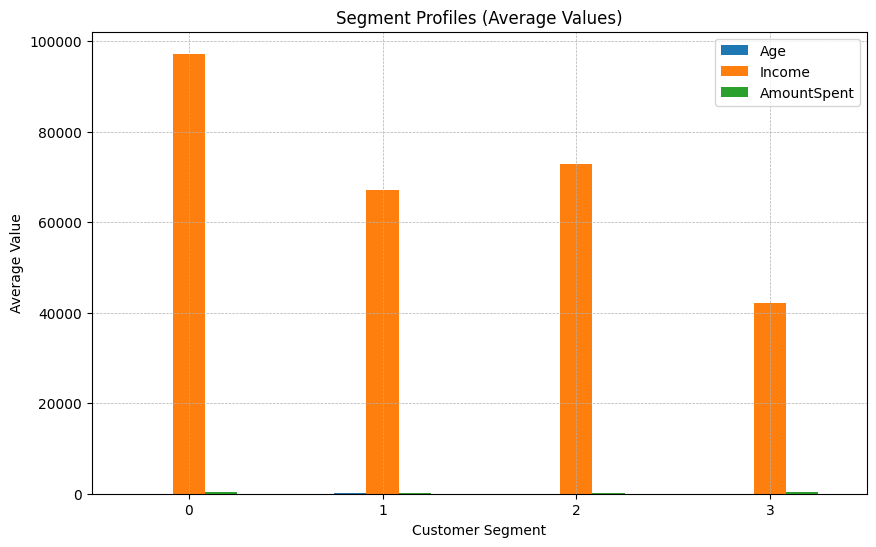

In [7]:
# Segment profiling with purchase preferences
profile_means = df.groupby("Segment")[["Age", "Income", "AmountSpent"]].mean().round(2)
counts = df.groupby("Segment").size().rename("Count")
cluster_profile = profile_means.join(counts)

# Add purchase distribution
purchase_mix = pd.crosstab(df["Segment"], df["Purchases"], normalize="index").round(3)
cluster_profile = cluster_profile.join(purchase_mix)

# Display cluster profile
cluster_profile

# Plot segment averages
profile_means.plot(kind="bar", figsize=(10,6))
plt.title("Segment Profiles (Average Values)")
plt.ylabel("Average Value")
plt.xlabel("Customer Segment")
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()